In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from my_helpers.general_helpers import load_json
from utilities.helpers import make_confusion_matrix, plot_confusion_matrix, mean_per_target_tool, \
    plot_target_tool_matrix, plot_tool_behavior_matrix, make_tool_behavior_matrix

from utilities.helpers import get_result_cross_tool_1to1, get_results_cross_beh_4to1, get_results_cross_tool_5to1, \
    make_target_tool_matrix, make_target_beh_matrix, plot_target_beh_matrix, get_result_cross_beh_1to1

import itertools
import configs
import os

In [3]:
ALL_TOOLS = configs.ALL_TOOL_LIST
ALL_BEHS = configs.ALL_BEH_LIST
ALL_OBJS = configs.SORTED_OBJ_LIST
BASE_DIR = "../test_result"

# Baseline1

In [4]:
import json
def plot_b1_result(results):
    import json
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # ------------------------
    # Define tools and behaviors
    # ------------------------
    ALL_TOOL_LIST = [
        'metal-scissor', 'metal-whisk', "plastic-knife",
        'plastic-spoon', "wooden-chopstick", 'wooden-fork'
    ]
    ALL_BEH_LIST = [
        '2-stirring-slow', '3-stirring-fast',
        '4-stirring-twist', '5-whisk', '6-poke'
    ]
    
    # ------------------------
    # Parse results
    # ------------------------
    rows = []
    for key, val in results.items():
        behavior = next((b for b in ALL_BEH_LIST if b in key), None)
        tool = next((t for t in ALL_TOOL_LIST if t in key), None)
    
        if behavior is None or tool is None:
            continue  # skip if parsing failed
    
        accuracies = val["accuracies"]
        mean = np.mean(accuracies)
        std = np.std(accuracies)
    
        rows.append({"tool": tool, "behavior": behavior, "mean": mean, "std": std})
    
    df = pd.DataFrame(rows)
    
    pivot_mean = df.pivot(index="tool", columns="behavior", values="mean")*100
    pivot_std = df.pivot(index="tool", columns="behavior", values="std")*100
    # ------------------------
    # Add averages across rows and columns
    # ------------------------
    # Row averages (across behaviors)
    pivot_mean["Avg(behaviors)"] = pivot_mean.mean(axis=1)
    pivot_std["Avg(behaviors)"] = pivot_mean.std(axis=1)
    
    # Column averages (across tools)
    pivot_mean.loc["Avg(tools)"] = pivot_mean.mean(axis=0)
    pivot_std.loc["Avg(tools)"] = pivot_mean.std(axis=0)
    
    # ------------------------
    # Create annotation table: mean ± std
    # ------------------------
    annotations = pivot_mean.round(2).astype(str) + "±" + pivot_std.round(2).astype(str)
    
    
    plt.figure(figsize=(12, 7))
    sns.heatmap(
        pivot_mean,
        annot=annotations,
        fmt="",
        cmap="YlGnBu",   # academic-friendly colormap
        cbar_kws={'label': 'Mean Accuracy'},
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='white'
    )
    
    plt.title("Tool × Behavior Accuracy (mean ± std)", fontsize=14)
    plt.ylabel("Tool", fontsize=12)
    plt.xlabel("Behavior", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return df, pivot_mean
        

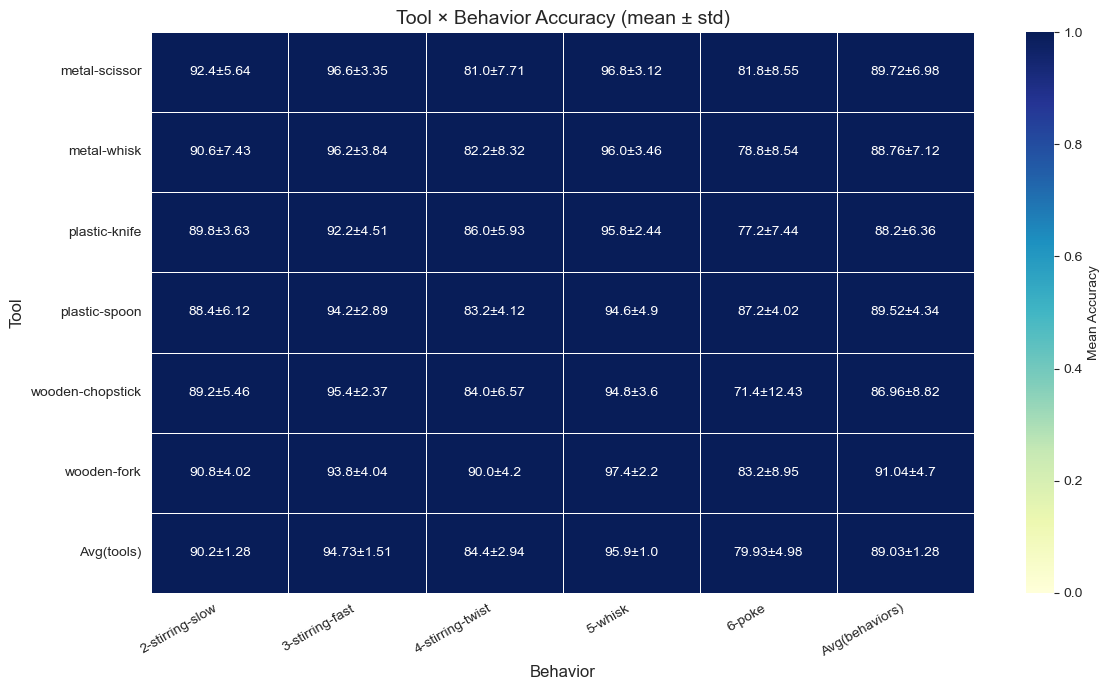

In [8]:
import json
b1_path = "../test_result/b1_result.json"
with open(b1_path, "r") as f:
    b1_results300 = json.load(f)
b1_df, b1_pivot_mean = plot_b1_result(b1_results300)

In [9]:
b1_pivot_mean

behavior,2-stirring-slow,3-stirring-fast,4-stirring-twist,5-whisk,6-poke,Avg(behaviors)
tool,,,,,,
metal-scissor,92.4,96.600000,81.0,96.8,81.800000,89.720000
metal-whisk,90.6,96.200000,82.2,96.0,78.800000,88.760000
plastic-knife,89.8,92.200000,86.0,95.8,77.200000,88.200000
plastic-spoon,88.4,94.200000,83.2,94.6,87.200000,89.520000
wooden-chopstick,89.2,95.400000,84.0,94.8,71.400000,86.960000
wooden-fork,90.8,93.800000,90.0,97.4,83.200000,91.040000
Avg(tools),90.2,94.733333,84.4,95.9,79.933333,89.033333


In [10]:
b1_tools_mean = b1_df.groupby("tool")["mean"].mean()
b1_tools_mean*100, b1_df.groupby("tool")["mean"].std()*100
# b1 tools

(tool
 metal-scissor       89.72
 metal-whisk         88.76
 plastic-knife       88.20
 plastic-spoon       89.52
 wooden-chopstick    86.96
 wooden-fork         91.04
 Name: mean, dtype: float64,
 tool
 metal-scissor       7.800769
 metal-whisk         7.959146
 plastic-knife       7.109149
 plastic-spoon       4.855100
 wooden-chopstick    9.856368
 wooden-fork         5.260038
 Name: mean, dtype: float64)

In [11]:
b1_behs_mean = b1_df.groupby("behavior")["mean"].mean()
b1_behs_mean*100, b1_df.groupby("behavior")["mean"].std()*100
# B1 behaviors

(behavior
 2-stirring-slow     90.200000
 3-stirring-fast     94.733333
 4-stirring-twist    84.400000
 5-whisk             95.900000
 6-poke              79.933333
 Name: mean, dtype: float64,
 behavior
 2-stirring-slow     1.397140
 3-stirring-fast     1.652473
 4-stirring-twist    3.222421
 5-whisk             1.093618
 6-poke              5.450382
 Name: mean, dtype: float64)

In [12]:
def get_all_cross_beh_1to1_results(tr_type):
    acc_dict = {}
    for t in ALL_TOOLS:
        cB_1to1_result = get_result_cross_beh_1to1(
            base_dir=BASE_DIR, transfer_type=tr_type, data_name="audio_20s_clap_emb_all.npz", 
            beh_list=ALL_BEHS, shared_tool=t, result_id=1, modality="audio"
        )
        acc_dict[t] = {}
        for combo_name in cB_1to1_result.keys():
            for k in cB_1to1_result[combo_name]:
                if k == "test_results":
                    acc_dict[t][combo_name] = cB_1to1_result[combo_name]['test_results']['avg_accuracy']
    return acc_dict

def get_all_cross_tool_1to1_results(tr_type):
    acc_dict = {}
    for b in ALL_BEHS:
        cT_1to1_result = get_result_cross_tool_1to1(
            base_dir=BASE_DIR, transfer_type=tr_type, data_name="audio_20s_clap_emb_all.npz", 
            tool_list=ALL_TOOLS, shared_beh=b, result_id=1, modality="audio"
        )
        acc_dict[b] = {}
        for combo_name in cT_1to1_result.keys():
            for k in cT_1to1_result[combo_name]:
                if k == "test_results":
                    acc_dict[b][combo_name] = cT_1to1_result[combo_name]['test_results']['avg_accuracy']
    return acc_dict


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def get_avg_1to1_cross(tr_type, cross_tool=True):
    avg_acc = {}
    std_acc = {}
    if cross_tool:
        cross_acc = get_all_cross_tool_1to1_results(tr_type)
        for combo in cross_acc['3-stirring-fast'].keys():
            avg_acc[combo] = []
            std_acc[combo] = []
    else:
        cross_acc = get_all_cross_beh_1to1_results(tr_type)
        for combo in cross_acc['metal-scissor'].keys():
            avg_acc[combo] = []
            std_acc[combo] = []
        
    for k in cross_acc.keys():
        for combo, accuracy in cross_acc[k].items():
            avg_acc[combo].append(accuracy)
    for combo, acc_list in avg_acc.items():
        avg_acc[combo] = np.mean(acc_list)
        std_acc[combo] = np.std(acc_list)
    return avg_acc, std_acc  

def build_confusion_matrix(acc_dict, std_dict):
    # Parse keys into source/target
    data = []
    sources, targets = set(), set()
    for key, mean in acc_dict.items():
        source, target = key.split(">")  # source is on the left side of target
        std = std_dict.get(key, np.nan)
        data.append((source, target, mean, std))
        sources.add(source)
        targets.add(target)

    # Create pivot tables
    df = pd.DataFrame(data, columns=["source", "target", "mean", "std"])
    pivot_mean = df.pivot(index="target", columns="source", values="mean")
    pivot_std = df.pivot(index="target", columns="source", values="std")

    # Annotation: mean ± std
    annotations = pivot_mean.round(2).astype(str) + "±" + pivot_std.round(2).astype(str)

    return pivot_mean, pivot_std, annotations

def plot_confusion_matrix(pivot_mean, annotations, title="Cross-Context Accuracy (mean ± std)"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        pivot_mean,
        annot=annotations,
        fmt="",
        cmap="YlGnBu",   # clean colormap for papers
        cbar_kws={'label': 'Mean Accuracy'},
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='white'
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Source Context ")
    plt.ylabel("Target Context ")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
def get_comparable_means(tr_type):
    # get the mean transfer accuracy and its std to the target tool and target behaviors
    
    # for cross tool, get average across behaviors
    ct_avg_acc, ct_std_acc = get_avg_1to1_cross(tr_type=tr_type, cross_tool=True)
    # draw confusion matrix, source tool as column, target tool as row
    ct_mean, _, ct_annotations = build_confusion_matrix(ct_avg_acc, ct_std_acc)
    plot_confusion_matrix(ct_mean, ct_annotations)
    
    # for cross behavior, get average across tools
    cb_avg_acc, cb_std_acc = get_avg_1to1_cross(tr_type=tr_type, cross_tool=False)
    # draw confusion matrix, source behavior as column, target behavior as row
    cb_mean, _, cb_annotations = build_confusion_matrix(cb_avg_acc, cb_std_acc)
    plot_confusion_matrix(cb_mean, cb_annotations)
    
    return {
        "ct_mean": ct_mean.mean(axis=1),  # axis=1 means to average among all source (columns)
        "ct_std": ct_mean.std(axis=1), 
        "cb_mean": cb_mean.mean(axis=1),
        "cb_std": ct_mean.std(axis=1)
    }

# B2

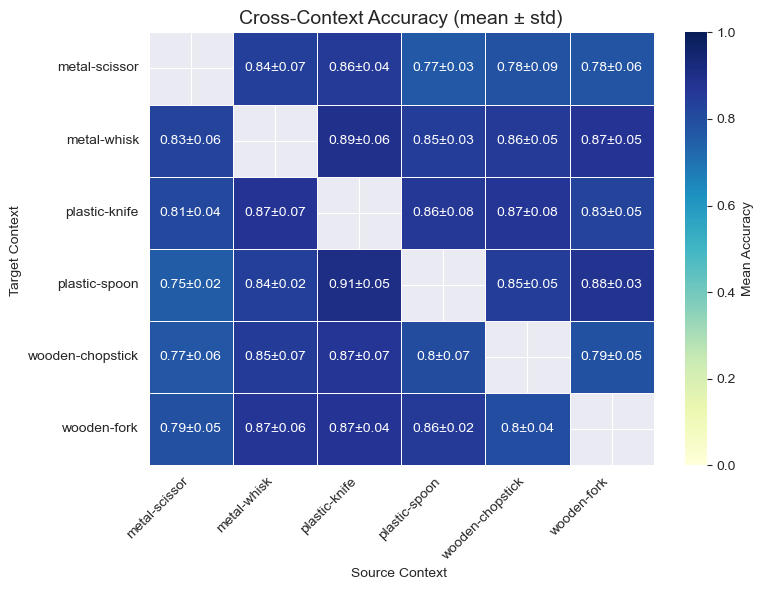

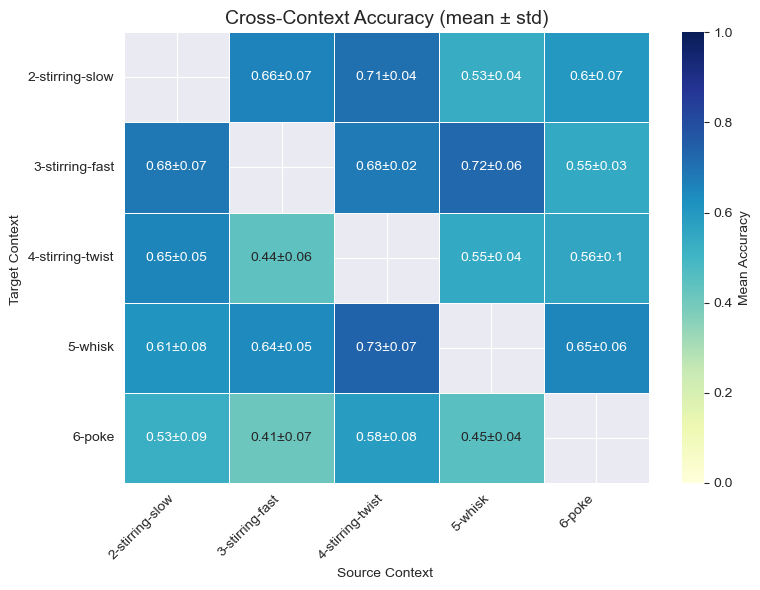

In [14]:
b2_avgs = get_comparable_means("baseline2_filter_obj")

In [15]:
b2_avgs['ct_mean']*100, b2_avgs['ct_std']*100  # B2 cross tool 1to1

(target
 metal-scissor       80.624
 metal-whisk         85.984
 plastic-knife       84.864
 plastic-spoon       84.664
 wooden-chopstick    81.664
 wooden-fork         83.864
 dtype: float64,
 target
 metal-scissor       4.129755
 metal-whisk         2.375643
 plastic-knife       2.636907
 plastic-spoon       5.756707
 wooden-chopstick    4.125298
 wooden-fork         4.095324
 dtype: float64)

In [16]:
b2_avgs['ct_mean'].mean()*100, b2_avgs['ct_mean'].std(ddof=0)*100

(83.61066666666666, 1.8746970125566649)

In [17]:
b2_avgs['cb_mean']*100, b2_avgs['cb_std']*100  # B2 cross behavior 1to1

(target
 2-stirring-slow     62.425000
 3-stirring-fast     65.875000
 4-stirring-twist    54.825000
 5-whisk             65.975000
 6-poke              49.308333
 dtype: float64,
 target
 metal-scissor       4.129755
 metal-whisk         2.375643
 plastic-knife       2.636907
 plastic-spoon       5.756707
 wooden-chopstick    4.125298
 wooden-fork         4.095324
 dtype: float64)

In [18]:
b2_avgs['cb_mean'].mean()*100, b2_avgs['cb_mean'].std()*100

(59.68166666666666, 7.3600705763524354)

In [19]:
b2_avgs['cb_mean']

target
2-stirring-slow     0.624250
3-stirring-fast     0.658750
4-stirring-twist    0.548250
5-whisk             0.659750
6-poke              0.493083
dtype: float64

In [20]:
np.std([62.425, 65.875, 54.825, 65.975, 49.308333])

6.583047356219019

In [21]:
b2_ct_avg_acc, b2_ct_std_acc = get_avg_1to1_cross(tr_type='baseline2_filter_obj', cross_tool=True)
b2_cb_avg_acc, b2_cb_std_acc = get_avg_1to1_cross(tr_type='baseline2_filter_obj', cross_tool=False)
b2_ct_avg_acc, b2_cb_avg_acc

({'metal-scissor>metal-whisk': 0.8300000000000001,
  'metal-scissor>plastic-knife': 0.8140000000000001,
  'metal-scissor>plastic-spoon': 0.7548,
  'metal-scissor>wooden-chopstick': 0.7727999999999999,
  'metal-scissor>wooden-fork': 0.7896,
  'metal-whisk>metal-scissor': 0.8428000000000001,
  'metal-whisk>plastic-knife': 0.8716000000000002,
  'metal-whisk>plastic-spoon': 0.8423999999999999,
  'metal-whisk>wooden-chopstick': 0.8512000000000001,
  'metal-whisk>wooden-fork': 0.8708,
  'plastic-knife>metal-scissor': 0.8583999999999999,
  'plastic-knife>metal-whisk': 0.8916000000000001,
  'plastic-knife>plastic-spoon': 0.906,
  'plastic-knife>wooden-chopstick': 0.8684000000000001,
  'plastic-knife>wooden-fork': 0.8748000000000001,
  'plastic-spoon>metal-scissor': 0.7672,
  'plastic-spoon>metal-whisk': 0.8472,
  'plastic-spoon>plastic-knife': 0.8603999999999999,
  'plastic-spoon>wooden-chopstick': 0.8027999999999998,
  'plastic-spoon>wooden-fork': 0.8588000000000001,
  'wooden-chopstick>metal

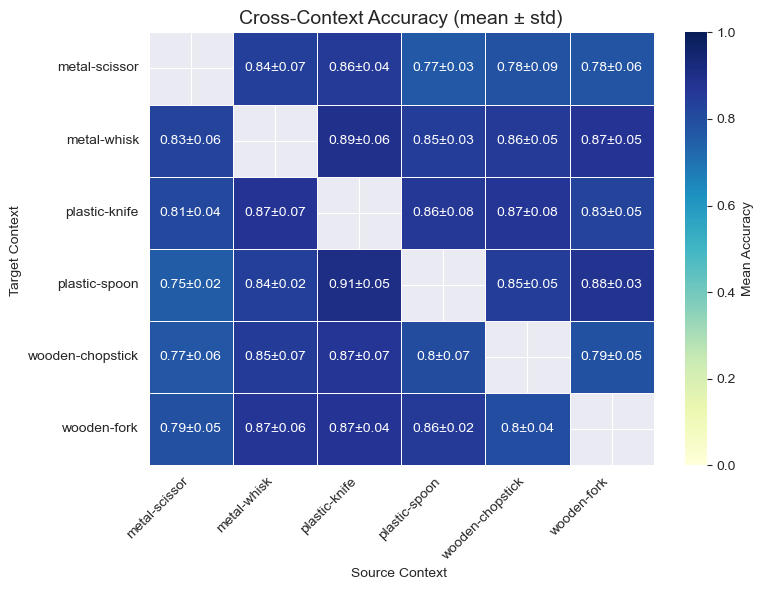

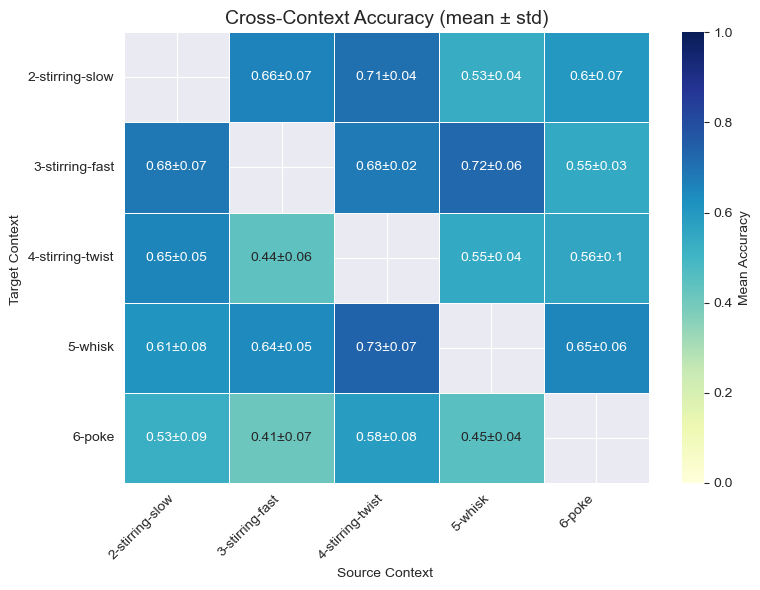

In [22]:
b2_avgs = get_comparable_means("baseline2_filter_obj")

In [23]:
b1_tools_mean - b2_avgs['ct_mean']

tool
metal-scissor       0.09096
metal-whisk         0.02776
plastic-knife       0.03336
plastic-spoon       0.04856
wooden-chopstick    0.05296
wooden-fork         0.07176
dtype: float64

In [24]:
b1_behs_mean - b2_avgs['cb_mean']

behavior
2-stirring-slow     0.277750
3-stirring-fast     0.288583
4-stirring-twist    0.295750
5-whisk             0.299250
6-poke              0.306250
dtype: float64

In [25]:
b1_behs_mean

behavior
2-stirring-slow     0.902000
3-stirring-fast     0.947333
4-stirring-twist    0.844000
5-whisk             0.959000
6-poke              0.799333
Name: mean, dtype: float64

# SINCERE

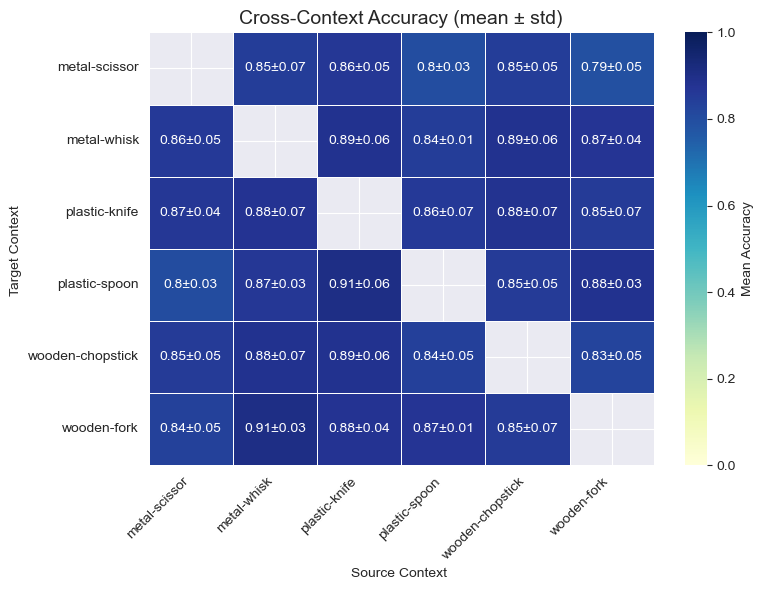

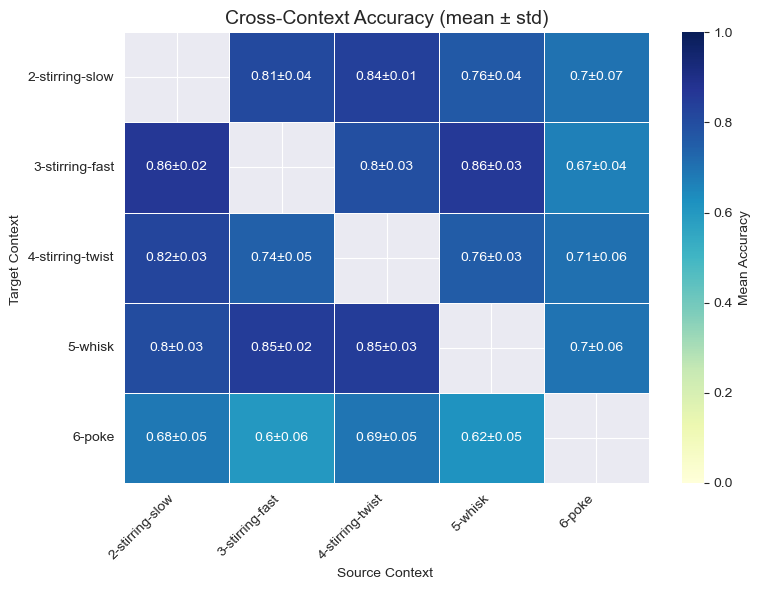

In [26]:
sin_avgs = get_comparable_means("shared_filter_obj")

In [27]:
sin_avgs['ct_mean']*100, sin_avgs['ct_std']*100  # sincere cross tool 1to1

(target
 metal-scissor       82.904
 metal-whisk         86.936
 plastic-knife       86.752
 plastic-spoon       86.232
 wooden-chopstick    85.712
 wooden-fork         86.840
 dtype: float64,
 target
 metal-scissor       3.280317
 metal-whisk         1.852911
 plastic-knife       1.189756
 plastic-spoon       3.899477
 wooden-chopstick    2.687810
 wooden-fork         2.645449
 dtype: float64)

In [28]:
sin_avgs['cb_mean']*100, sin_avgs['cb_std']*100 # sincere cross beh 1to1

(target
 2-stirring-slow     77.841667
 3-stirring-fast     79.566667
 4-stirring-twist    75.741667
 5-whisk             80.033333
 6-poke              64.908333
 dtype: float64,
 target
 metal-scissor       3.280317
 metal-whisk         1.852911
 plastic-knife       1.189756
 plastic-spoon       3.899477
 wooden-chopstick    2.687810
 wooden-fork         2.645449
 dtype: float64)

In [29]:
b1_tools_mean-sin_avgs['ct_mean']

tool
metal-scissor       0.06816
metal-whisk         0.01824
plastic-knife       0.01448
plastic-spoon       0.03288
wooden-chopstick    0.01248
wooden-fork         0.04200
dtype: float64

In [30]:
b1_behs_mean-sin_avgs['cb_mean']

behavior
2-stirring-slow     0.123583
3-stirring-fast     0.151667
4-stirring-twist    0.086583
5-whisk             0.158667
6-poke              0.150250
dtype: float64